In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12  # matches paris3_sc_brute.py
N_SEGS = 6  # must match --n-segs used to build the brute-force LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780     # fixed: not searched
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

print("Setting up log_density and prior functions...")

# S schedule: jump to next S after stuck_iters of no improvement
S_schedule  = [3.0, 10.0, 30.0]
stuck_iters = 10000

# annealing dict
anneal_state = {
    'S':              S_schedule[0],
    'stage':          0,         # index into S_schedule
    'ref_max_ld':     None,      # max_ld at last check
    'ref_iter':       0,
    'stuck_count':    0,
}


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    h_stack, idx_ok = [], []
    for i in range(params.shape[0]):
        (logm1, logm2, a_i, p0_i, e0_i, dist_i,
         cos_qS_i, phiS_i, cos_qK_i, phiK_i, Phi_phi0_i, Phi_r0_i) = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            qK_i = np.arccos(cos_qK_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist_i, qS_i, phiS_i, qK_i, phiK_i,
                Phi_phi0_i, Phi_theta0, Phi_r0_i,
                T=T, dt=dt,
            ))
            h_stack.append(h_temp)
            idx_ok.append(i)
        except Exception:
            pass
    if h_stack:
        h_batch = gwf.xp.stack(h_stack, axis=0)  # (b, n_chan, N)
        snr = gwf.SNR_semicoherent_batch(loglike_obj.signal, h_batch, N_seg=N_SEGS, phase_max=True)
        for k, i in enumerate(idx_ok):
            out[i] = float(snr[k]) #* anneal_state['S']
    return out


# Same priors as the merging stage (paris3_sc_brute.py) -- same bounds as
# run_lhs_noise_sc_brute.py. xI0 and Phi_theta0 held fixed (not searched);
# sky/spin polar angles sampled uniform in cosine.
LOGM1_LIM = [5.81854, 5.83713]
LOGM2_LIM = [1.99115, 1.99507]
A_LIM     = [0.49296, 0.51048]
P0_LIM    = [15.53112, 15.88282]
E0_LIM    = [0.74301, 0.74536]
DIST_LIM  = [3,  5]
COSQS_LIM = [-1.0, 1.0]
PHIS_LIM  = [0.0,  2 * np.pi]
COSQK_LIM = [-1.0, 1.0]
PHIK_LIM  = [0.0,  2 * np.pi]
PHIPHI0_LIM = [0.0, 2 * np.pi]
PHIR0_LIM   = [0.0, 2 * np.pi]


def prior_transform(u):
    t = np.zeros_like(u)
    t[:, 0]  = (LOGM1_LIM[1] - LOGM1_LIM[0]) * u[:, 0] + LOGM1_LIM[0]
    t[:, 1]  = (LOGM2_LIM[1] - LOGM2_LIM[0]) * u[:, 1] + LOGM2_LIM[0]
    t[:, 2]  = (A_LIM[1] - A_LIM[0]) * u[:, 2] + A_LIM[0]
    t[:, 3]  = (P0_LIM[1] - P0_LIM[0]) * u[:, 3] + P0_LIM[0]
    t[:, 4]  = (E0_LIM[1] - E0_LIM[0]) * u[:, 4] + E0_LIM[0]
    t[:, 5]  = (DIST_LIM[1] - DIST_LIM[0]) * u[:, 5] + DIST_LIM[0]
    t[:, 6]  = (COSQS_LIM[1] - COSQS_LIM[0]) * u[:, 6] + COSQS_LIM[0]
    t[:, 7]  = (PHIS_LIM[1] - PHIS_LIM[0]) * u[:, 7] + PHIS_LIM[0]
    t[:, 8]  = (COSQK_LIM[1] - COSQK_LIM[0]) * u[:, 8] + COSQK_LIM[0]
    t[:, 9]  = (PHIK_LIM[1] - PHIK_LIM[0]) * u[:, 9] + PHIK_LIM[0]
    t[:, 10] = (PHIPHI0_LIM[1] - PHIPHI0_LIM[0]) * u[:, 10] + PHIPHI0_LIM[0]
    t[:, 11] = (PHIR0_LIM[1] - PHIR0_LIM[0]) * u[:, 11] + PHIR0_LIM[0]
    return t


def inverse_prior_transform(params):
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0]  = (params[:, 0] - LOGM1_LIM[0]) / (LOGM1_LIM[1] - LOGM1_LIM[0])
    u[:, 1]  = (params[:, 1] - LOGM2_LIM[0]) / (LOGM2_LIM[1] - LOGM2_LIM[0])
    u[:, 2]  = (params[:, 2] - A_LIM[0]) / (A_LIM[1] - A_LIM[0])
    u[:, 3]  = (params[:, 3] - P0_LIM[0]) / (P0_LIM[1] - P0_LIM[0])
    u[:, 4]  = (params[:, 4] - E0_LIM[0]) / (E0_LIM[1] - E0_LIM[0])
    u[:, 5]  = (params[:, 5] - DIST_LIM[0]) / (DIST_LIM[1] - DIST_LIM[0])
    u[:, 6]  = (params[:, 6] - COSQS_LIM[0]) / (COSQS_LIM[1] - COSQS_LIM[0])
    u[:, 7]  = (params[:, 7] - PHIS_LIM[0]) / (PHIS_LIM[1] - PHIS_LIM[0])
    u[:, 8]  = (params[:, 8] - COSQK_LIM[0]) / (COSQK_LIM[1] - COSQK_LIM[0])
    u[:, 9]  = (params[:, 9] - PHIK_LIM[0]) / (PHIK_LIM[1] - PHIK_LIM[0])
    u[:, 10] = (params[:, 10] - PHIPHI0_LIM[0]) / (PHIPHI0_LIM[1] - PHIPHI0_LIM[0])
    u[:, 11] = (params[:, 11] - PHIR0_LIM[0]) / (PHIR0_LIM[1] - PHIR0_LIM[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1, N_segs=6
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Setting up log_density and prior functions...


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage2_anneal_brute/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
len(sampler.now_covariances)

1

In [5]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.82813911,  1.993131  ,  0.5022269 , 15.68879892,  0.74340251,
         4.60222267,  0.83080315,  3.55846403,  0.66897301,  2.81934603,
         1.29602379,  3.40790301]])

In [6]:
log_density(maxld_pt1)

array([98.02294296])

In [7]:
log_density([param_true])

array([100.60446665])

In [8]:
param_ranges = [(LOGM1_LIM[0], LOGM1_LIM[1]),
                (LOGM2_LIM[0], LOGM2_LIM[1]),
                (A_LIM[0], A_LIM[1]),
                (P0_LIM[0], P0_LIM[1]),
                (E0_LIM[0], E0_LIM[1]),
                (DIST_LIM[0], DIST_LIM[1]),
                (COSQS_LIM[0], COSQS_LIM[1]),
                (PHIS_LIM[0], PHIS_LIM[1]),
                (COSQK_LIM[0], COSQK_LIM[1]),
                (PHIK_LIM[0], PHIK_LIM[1]),
                (PHIPHI0_LIM[0], PHIPHI0_LIM[1]),
                (PHIR0_LIM[0], PHIR0_LIM[1])]

param_ranges

[(5.81854, 5.83713),
 (1.99115, 1.99507),
 (0.49296, 0.51048),
 (15.53112, 15.88282),
 (0.74301, 0.74536),
 (3, 5),
 (-1.0, 1.0),
 (0.0, 6.283185307179586),
 (-1.0, 1.0),
 (0.0, 6.283185307179586),
 (0.0, 6.283185307179586),
 (0.0, 6.283185307179586)]

In [9]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 4.755,
 0.8306067129371271,
 3.5808,
 0.38950706335529234,
 3.8495,
 3.194,
 0.6038]

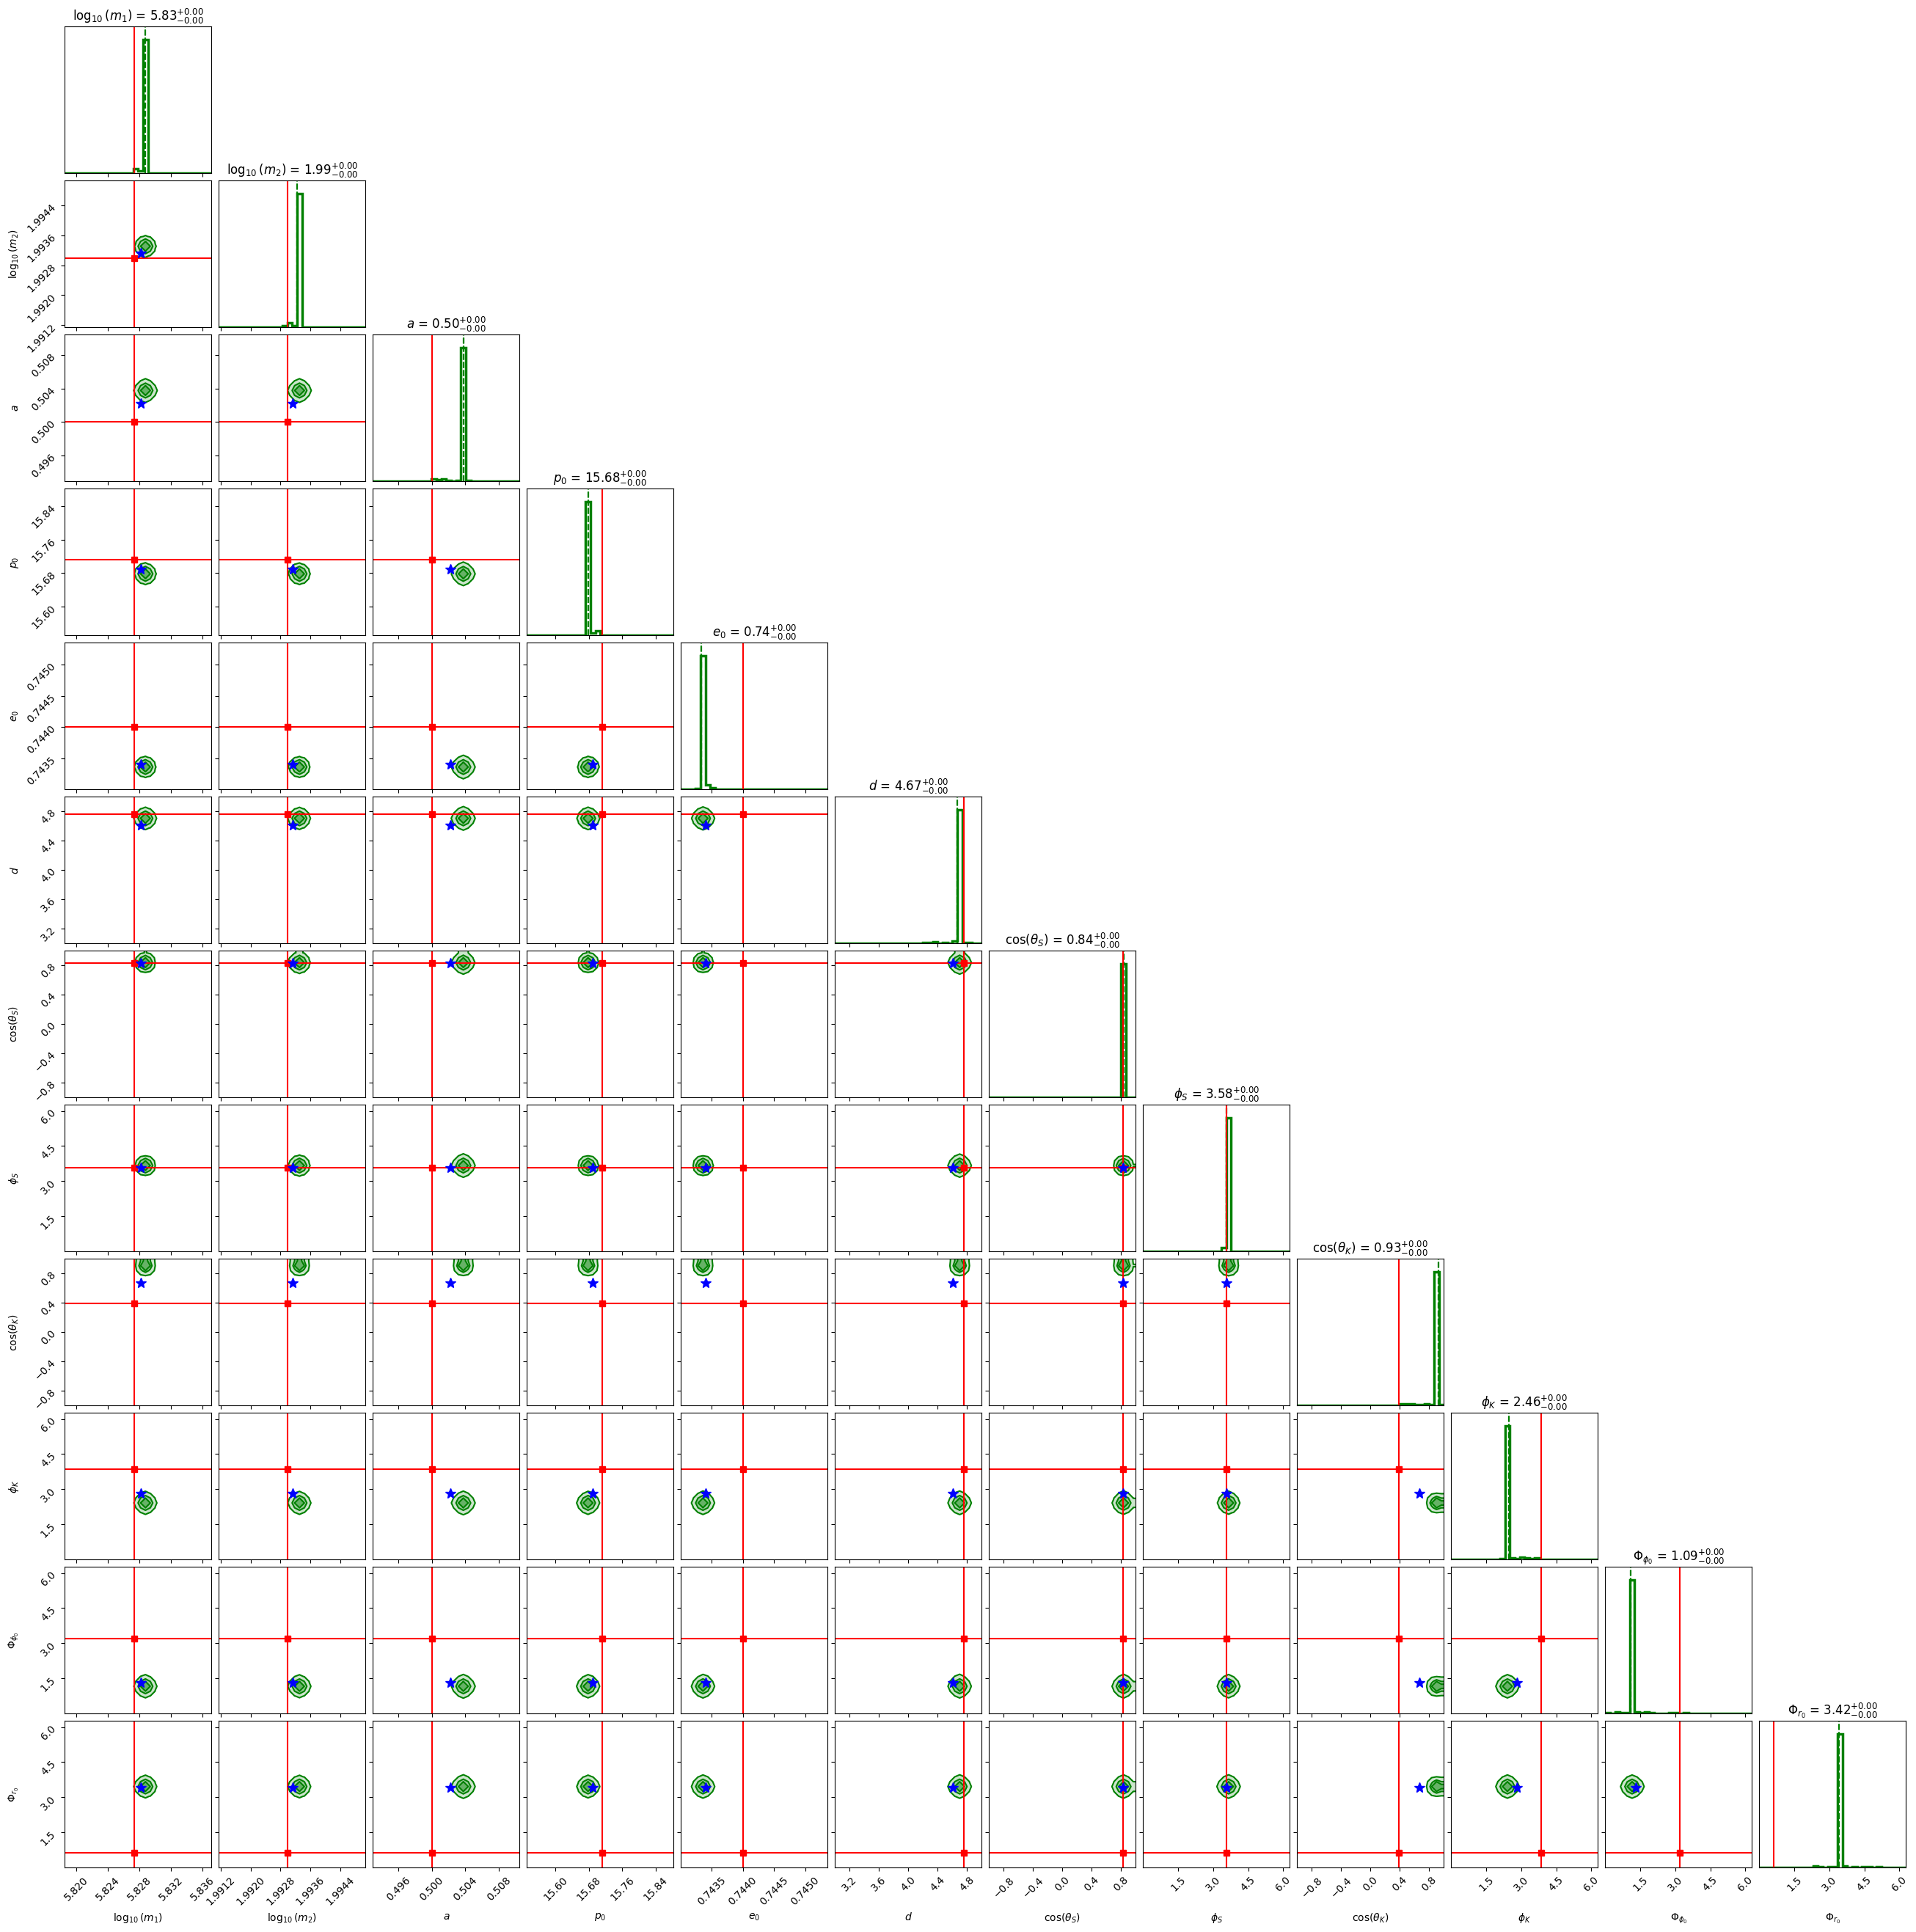

In [10]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$d$', r'$\cos(\theta_S)$', r'$\phi_S$', r'$\cos(\theta_K)$', r'$\phi_K$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

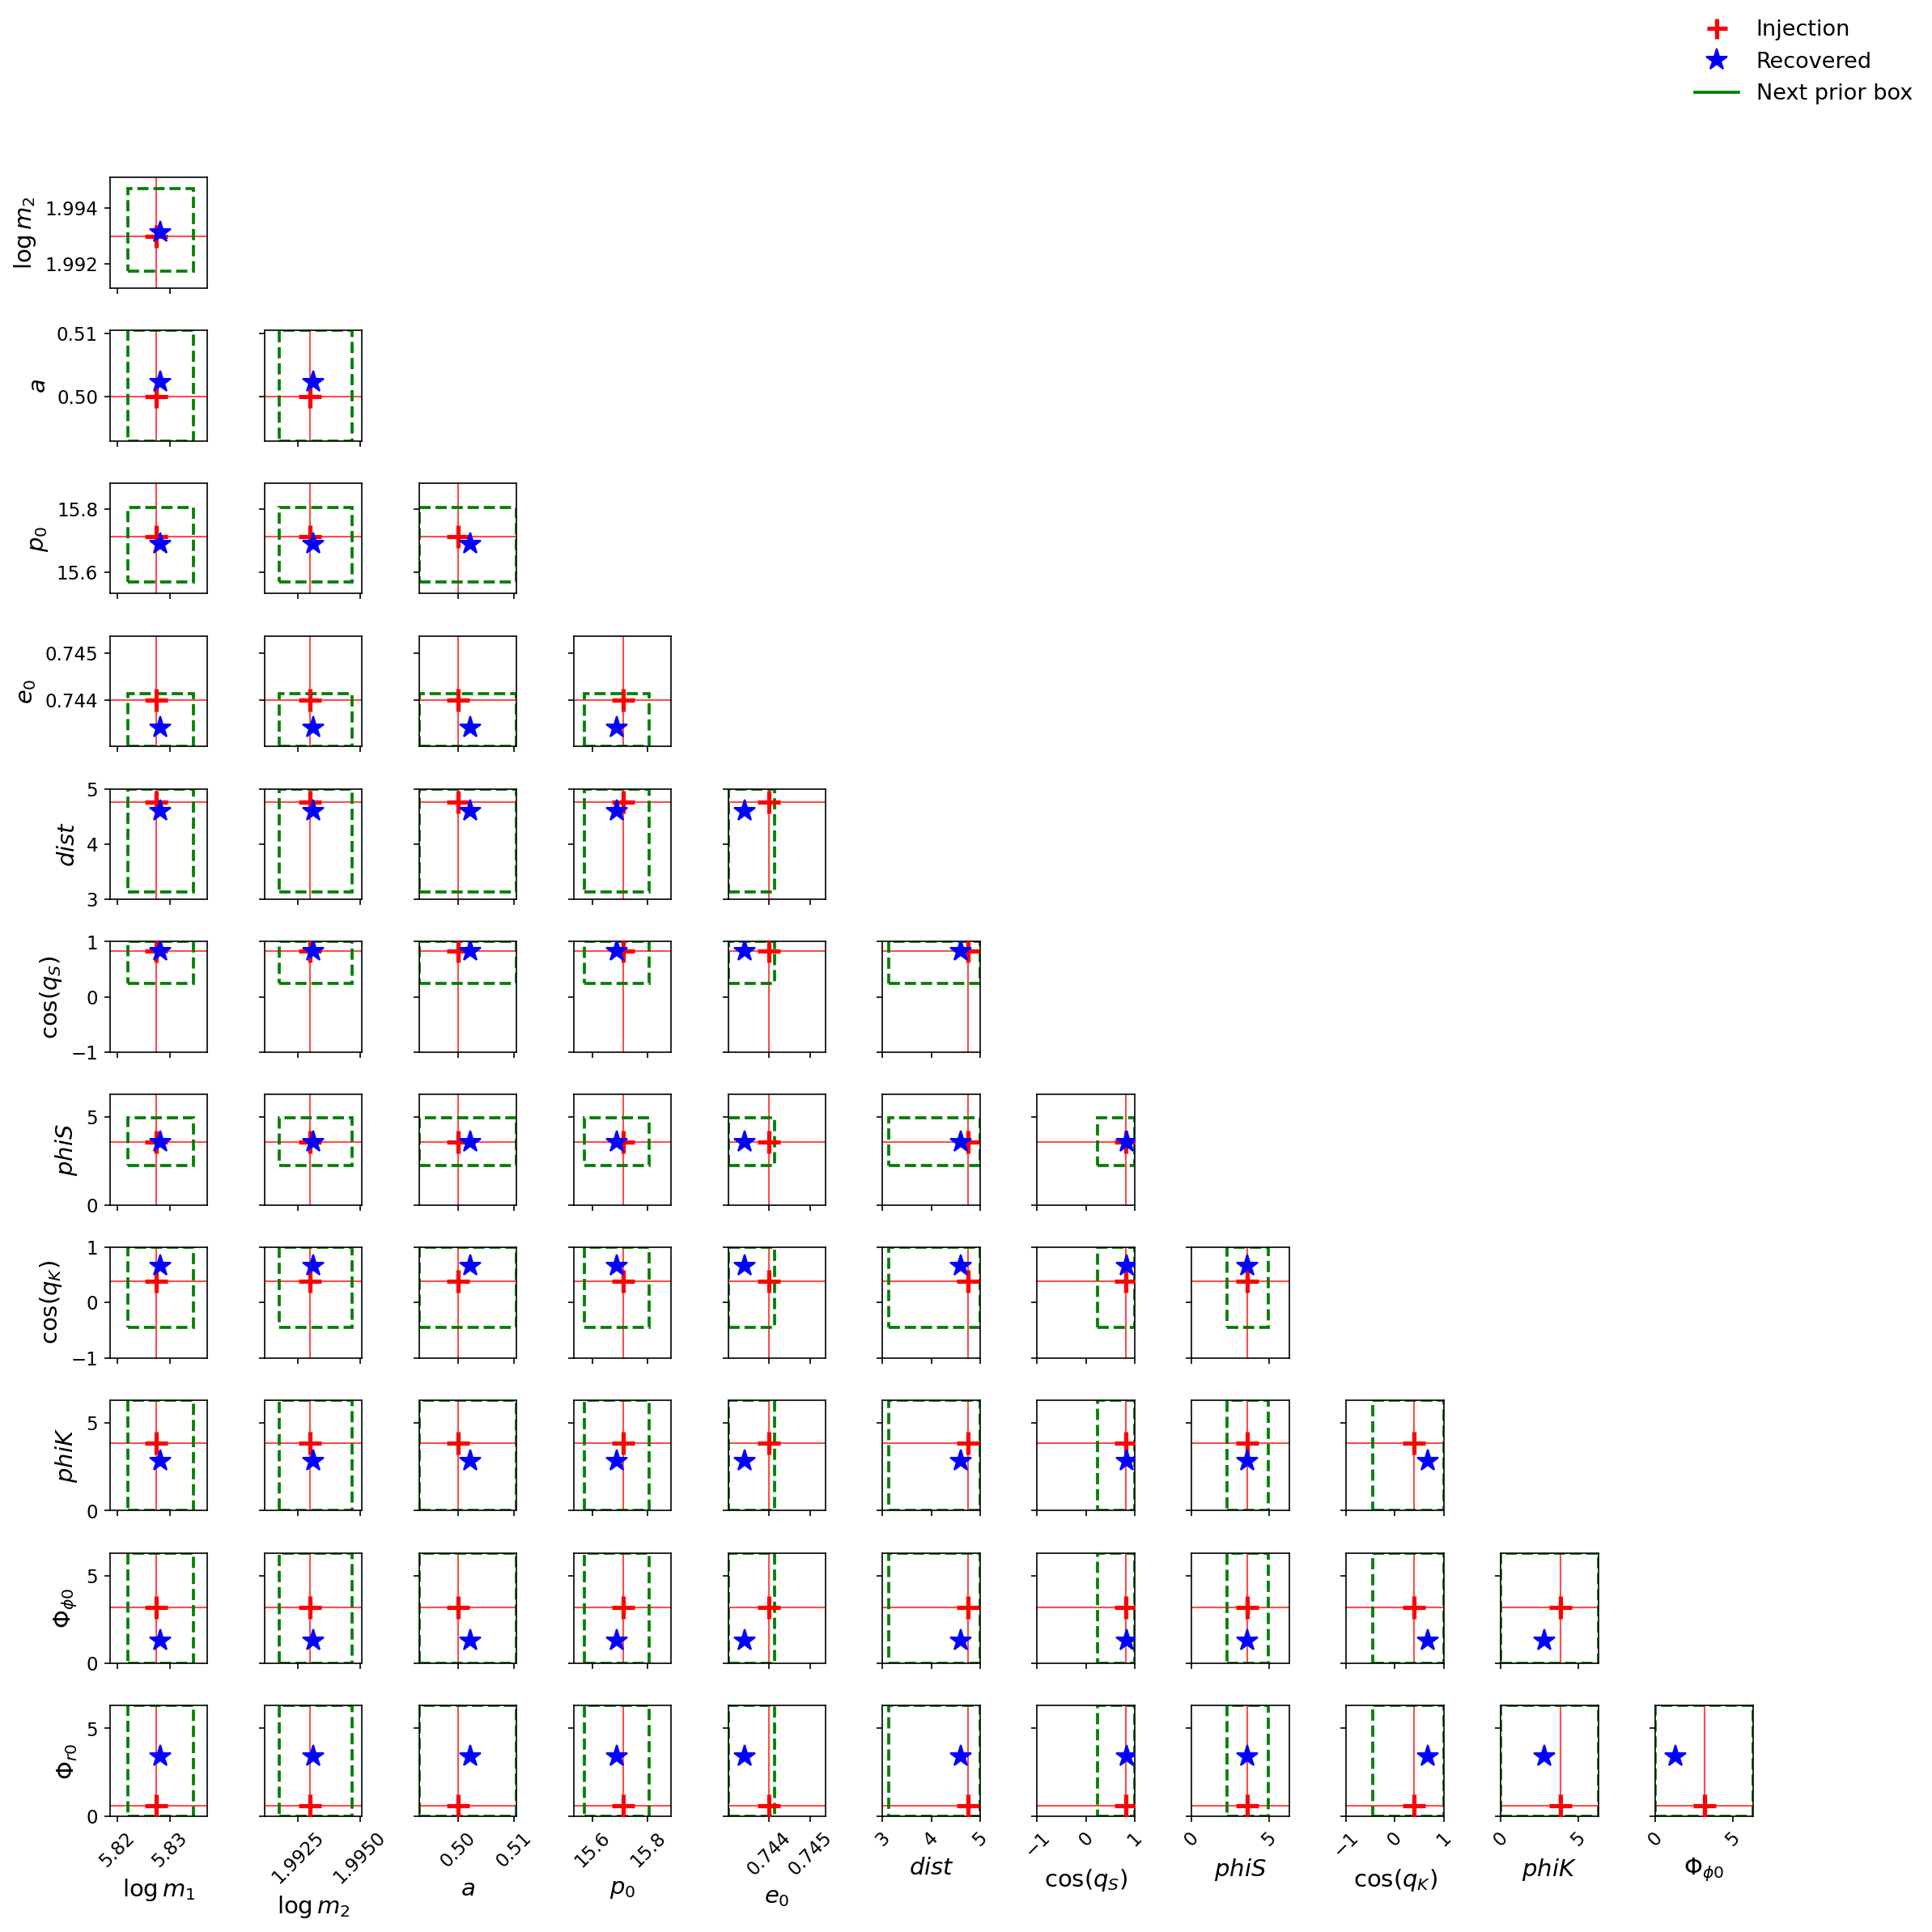

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$dist$',
          r'$\cos(q_S)$', r'$phiS$', r'$\cos(q_K)$', r'$phiK$',
          r'$\Phi_{\phi0}$', r'$\Phi_{r0}$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

box_lo = np.array([5.82203, 1.99187, 0.49296, 15.57419, 0.74301, 3.29828,
                    0.75625, 3.35513, -1.00000, 0.00000, 0.00000, 0.00000])
box_hi = np.array([5.83449, 1.99468, 0.51048, 15.80540, 0.74413, 5.00000,
                    1.00000, 4.96153,  1.00000, 6.28319, 6.28319, 6.28319])




fig, axes = plt.subplots(ndim, ndim, figsize=(16, 16))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # box overlay
        ax.add_patch(Rectangle(
            (box_lo[j], box_lo[i]),
            box_hi[j] - box_lo[j],
            box_hi[i] - box_lo[i],
            facecolor='none', edgecolor='green', lw=1.8, zorder=2,linestyle='--',
        ))

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
    Line2D([0], [0], color='green',  lw=1.8,                            label=r'Next prior box'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [12]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82813911,  1.993131  ,  0.5022269 , 15.68879892,  0.74340251,
         4.60222267,  0.83080315,  3.55846403,  0.66897301,  2.81934603,
         1.29602379,  3.40790301]])

In [13]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [14]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


OutOfMemoryError: Out of memory allocating 60,750,000,128 bytes (allocated so far: 132,610,356,736 bytes).

In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


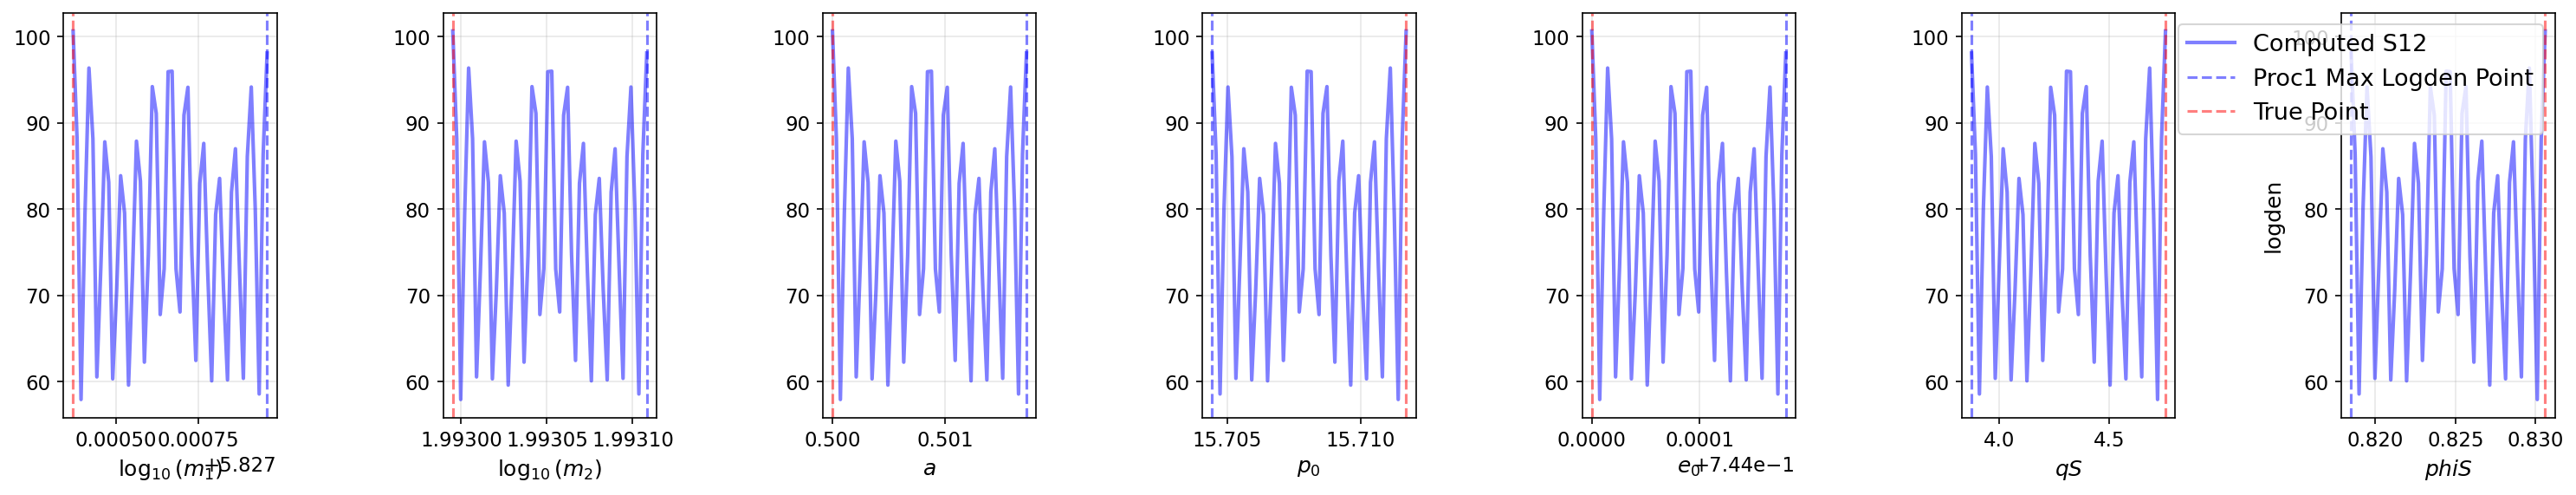

In [ ]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S12')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [15]:
# Bootstrap-resample the weighted posterior (same as paris3_lhs_s6_ext.py)
weights_norm = weights / weights.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples), size=50_000, replace=True, p=weights_norm)
cov_posterior = np.cov(samples[idx_rs].T)
sigma_diag = np.sqrt(np.diag(cov_posterior))

mu_center = maxld_pt1.ravel()          # max-log-density point (== mu_center in the script)
param_true_arr = np.asarray(param_true).ravel()

n_sigma_needed = (param_true_arr - mu_center) / sigma_diag

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'dist', 'cosqS', 'phiS', 'cosqK', 'phiK', 'Phi_phi0', 'Phi_r0']
for name, mu, sig, ns in zip(param_names, mu_center, sigma_diag, n_sigma_needed):
    print(f'{name:8s}: mu={mu:.5f}  sigma={sig:.5f}  true offset = {ns:+.2f} sigma')

print(f'\nMax |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): '
      f'{np.max(np.abs(n_sigma_needed)):.2f}')

logm1   : mu=5.82814  sigma=0.00020  true offset = -3.78 sigma
logm2   : mu=1.99313  sigma=0.00004  true offset = -3.23 sigma
a       : mu=0.50223  sigma=0.00058  true offset = -3.81 sigma
p0      : mu=15.68880  sigma=0.00382  true offset = +5.99 sigma
e0      : mu=0.74340  sigma=0.00002  true offset = +25.18 sigma
dist    : mu=4.60222  sigma=0.04346  true offset = +3.51 sigma
cosqS   : mu=0.83080  sigma=0.00248  true offset = -0.08 sigma
phiS    : mu=3.55846  sigma=0.00678  true offset = +3.30 sigma
cosqK   : mu=0.66897  sigma=0.07742  true offset = -3.61 sigma
phiK    : mu=2.81935  sigma=0.15222  true offset = +6.77 sigma
Phi_phi0: mu=1.29602  sigma=0.19700  true offset = +9.63 sigma
Phi_r0  : mu=3.40790  sigma=0.15771  true offset = -17.78 sigma

Max |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): 25.18


In [16]:
sigma_diag

array([2.03573340e-04, 4.20434687e-05, 5.84087175e-04, 3.82044243e-03,
       2.37243002e-05, 4.34646485e-02, 2.48497105e-03, 6.77783194e-03,
       7.74194601e-02, 1.52215554e-01, 1.97000418e-01, 1.57707341e-01])

In [17]:
# Prior bounds (same as paris3_lhs_s6_ext.py / stage1_anneal_s12 prior)
p1_lo = np.array([LOGM1_LIM[0], LOGM2_LIM[0], A_LIM[0], P0_LIM[0], E0_LIM[0], DIST_LIM[0], COSQS_LIM[0], PHIS_LIM[0], COSQK_LIM[0], PHIK_LIM[0], PHIPHI0_LIM[0], PHIR0_LIM[0]])
p1_hi = np.array([LOGM1_LIM[1], LOGM2_LIM[1], A_LIM[1], P0_LIM[1], E0_LIM[1], DIST_LIM[1], COSQS_LIM[1], PHIS_LIM[1], COSQK_LIM[1], PHIK_LIM[1], PHIPHI0_LIM[1], PHIR0_LIM[1]])

N_SIGMA = 30
print(f'N_SIGMA = {N_SIGMA:.0f}')

ellipse_lo = np.clip(mu_center - N_SIGMA * sigma_diag, p1_lo, p1_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA * sigma_diag, p1_lo, p1_hi)
box_width  = ellipse_hi - ellipse_lo
full_width = p1_hi - p1_lo

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'dist', 'cosqS', 'phiS', 'cosqK', 'phiK', 'Phi_phi0', 'Phi_r0']
for name, lo, hi, w, fw in zip(param_names, ellipse_lo, ellipse_hi, box_width, full_width):
    print(f'{name:8s}: [{lo:.5f}, {hi:.5f}]  width={w:.5f}  '
          f'({100*w/fw:.2f}% of full prior width)')

vol_frac = np.prod(box_width / full_width)
print(f'\nBox volume fraction of full prior box: {vol_frac:.3e}  (log10 = {np.log10(vol_frac):.2f})')


N_SIGMA = 30
logm1   : [5.82203, 5.83425]  width=0.01221  (65.70% of full prior width)
logm2   : [1.99187, 1.99439]  width=0.00252  (64.35% of full prior width)
a       : [0.49296, 0.51048]  width=0.01752  (100.00% of full prior width)
p0      : [15.57419, 15.80341]  width=0.22923  (65.18% of full prior width)
e0      : [0.74301, 0.74411]  width=0.00110  (46.99% of full prior width)
dist    : [3.29828, 5.00000]  width=1.70172  (85.09% of full prior width)
cosqS   : [0.75625, 0.90535]  width=0.14910  (7.45% of full prior width)
phiS    : [3.35513, 3.76180]  width=0.40667  (6.47% of full prior width)
cosqK   : [-1.00000, 1.00000]  width=2.00000  (100.00% of full prior width)
phiK    : [0.00000, 6.28319]  width=6.28319  (100.00% of full prior width)
Phi_phi0: [0.00000, 6.28319]  width=6.28319  (100.00% of full prior width)
Phi_r0  : [0.00000, 6.28319]  width=6.28319  (100.00% of full prior width)

Box volume fraction of full prior box: 5.316e-04  (log10 = -3.27)
